# MalthusJAX Level 2: Crossover Operators Tutorial

This notebook demonstrates the crossover operators in MalthusJAX, which implement **genetic recombination** - the process of combining genetic material from two parent individuals to create offspring.

## What is Crossover?

**Crossover** (also called *recombination*) is a fundamental genetic operator that:
- Takes two or more parent genomes as input
- Combines their genetic material to produce offspring
- Promotes **exploration** of the search space by mixing successful traits
- Balances **exploitation** (preserving good genes) with **exploration** (novel combinations)

## MalthusJAX 3-Tier Paradigm

All crossover operators follow the **3-Tier Architecture**:

1. **Tier 3 (RNG)**: Random key management and splitting
2. **Tier 2 (Noise Generation)**: Generate stochastic parameters (masks, indices, etc.)
3. **Tier 1 (Pure Arithmetic)**: Deterministic recombination logic

This design enables:
- **JIT compilation** for maximum performance
- **Reproducible** results with explicit random keys
- **Vectorization** over populations
- **GPU acceleration** via pure JAX functions

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np
import matplotlib.pyplot as plt
from typing import cast, Any
from time import time

from malthusjax.core.genome.binary_genome import BinaryGenome, BinaryGenomeConfig, BinaryPopulation
from malthusjax.core.genome.real_genome import RealGenome, RealGenomeConfig, RealPopulation

from malthusjax.operators.crossover.binary import UniformCrossover as BinaryUniformCrossover
from malthusjax.operators.crossover.binary import SinglePointCrossover

from malthusjax.operators.crossover.real import (
    UniformCrossover as RealUniformCrossover,
    BlendCrossover,
    SimulatedBinaryCrossover,
    BinomialCrossover
)

print(f"JAX version: {jax.__version__}")
print(f"JAX backend: {jax.default_backend()}")
print(f"Available devices: {jax.devices()}")

key = jr.PRNGKey(42)

JAX version: 0.8.0
JAX backend: cpu
Available devices: [CpuDevice(id=0)]


## Part 1: Binary Crossover Operators

Binary crossover operators work on bit strings and are fundamental to combinatorial optimization.

### Uniform Crossover (Binary)

**Uniform Crossover** creates offspring by independently deciding for each bit position whether to take the bit from Parent 1 or Parent 2, based on a crossover probability.

**Algorithm**:
1. For each bit position i: Generate random probability p_i
2. If p_i < crossover_rate: Take bit from Parent 2
3. Otherwise: Take bit from Parent 1

**Characteristics**:
- **Disruption**: High (can break up adjacent gene blocks)
- **Exploration**: Excellent for mixing distant genetic material
- **Parameter**: `crossover_rate` (typically 0.5 for balanced mixing)

In [2]:
BINARY_LENGTH = 20
POP_SIZE = 10

binary_config = BinaryGenomeConfig(shape=(BINARY_LENGTH,), p=0.5)
key, subkey = jr.split(key)
subkey_1, subkey_2 = jr.split(subkey)
binary_pop_1 = BinaryPopulation.init_random(subkey_1, binary_config, size=POP_SIZE)
binary_pop_2 = BinaryPopulation.init_random(subkey_2, binary_config, size=POP_SIZE)

print(f"Binary population size: {len(binary_pop_1)}")
print(f"Genome length: {BINARY_LENGTH}")
print(f"First individual: {binary_pop_1[0].values}")

uniform_crossover = BinaryUniformCrossover(
    num_offspring=1,
    input_length=POP_SIZE,
    crossover_rate=0.7
)
    

Binary population size: 10
Genome length: 20
First individual: [1 1 1 0 0 1 1 0 0 1 0 0 1 1 0 1 1 1 0 1]


### Prepare PRNG keys for the crossover operator

1. Split the global `key` to obtain a fresh `subkey` (avoid reusing the same PRNG key)
2. Ask the operator how many atomic keys it needs for a single batched operation via
    `uniform_crossover.num_keys(shape)`. This depends on the genome shape and operator internals
3. Split the `subkey` into `num_keys` independent keys to feed the operator's Tier-3 RNG layer

The resulting `crossover_keys` has shape (num_keys, 2) (each key is a 2-element uint32 PRNG key)
and can be passed directly to the crossover operator

In [3]:
# Apply bit flip mutation (prepare keys for crossover)
key, subkey = jr.split(key)
num_keys = uniform_crossover.num_keys(binary_pop_1.genes.values.shape)
crossover_keys = jr.split(subkey, num_keys)


print(f"Required keys: {num_keys}")
print(f"Keys shape: {crossover_keys.shape}")


Required keys: 10
Keys shape: (10, 2)


### Create an offspring by selecting bits from two binary parents using a boolean mask

1. Generate a boolean mask of the same shape as a genome that will work as the noise for the crossover:
    mask = jr.bernoulli(jr.PRNGKey(0), p=0.5, shape=binary_pop_1[0].values.shape)
    - Each True indicates "take bit from parent1" and False "take bit from parent2".
    - Note: using a fixed PRNGKey(0) is deterministic for demonstration; in practice
      split and pass a fresh key to avoid key reuse.

2. Build the per-bit result:
    result = jnp.where(mask, binary_pop_1[0].values, binary_pop_2[0].values)
    - Elementwise selection from parent genomes.

3. Wrap the raw values back into a BinaryGenome while preserving immutability:
    cast(BinaryGenome, cast(Any, binary_pop_1[0]).replace(values=result))
    - `replace` produces a new dataclass instance; the double `cast` assists type checkers.

In [4]:
jr.PRNGKey(0)

Array([0, 0], dtype=uint32)

In [5]:
mask = jr.bernoulli(jr.PRNGKey(0), p=0.5, shape=binary_pop_1[0].values.shape)
result = jnp.where(mask, binary_pop_1[0].values, binary_pop_2[0].values)
print(f"Mask:\n{mask}")

Mask:
[False False  True  True False  True  True False False  True False  True
 False False False False False False False  True]


In [6]:
jr.split(jr.PRNGKey(0), uniform_crossover.num_keys_per_atomic_operation)

Array([[1797259609, 2579123966]], dtype=uint32)

In [7]:
mask2 = uniform_crossover._generate_noise([jr.PRNGKey(0)],
                                          config= binary_config
                                          )
print(f"Generated mask:\n{mask2}")

Generated mask:
[False False  True  True  True  True  True  True False  True False  True
  True  True False False False False  True  True]


### Pass the noise vector to the single call crossover operator

In [8]:
off_1 = uniform_crossover._recombine_one(
            p1=binary_pop_1[0],
            p2=binary_pop_2[0],
            noise_data=mask,
            config=binary_config
        )

off_2 = uniform_crossover._recombine_one(
            p1=binary_pop_1[0],
            p2=binary_pop_2[0],
            noise_data=mask2,
            config=binary_config
        )

print(f"Offspring 1:\n{off_1.values}")
print(f"Offspring 2:\n{off_2.values}")


Offspring 1:
[1 0 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 0 0 1]
Offspring 2:
[1 0 1 0 0 1 1 0 0 1 1 0 1 1 0 0 0 0 0 1]


the whole process can be encapsulated in a single call to the crossover operator, passing the prepared keys and parent populations

In [9]:
crossover_pop = uniform_crossover(crossover_keys, binary_pop_1, binary_pop_2, binary_config)

print(f"\nOriginal population size: {len(binary_pop_1)} and {len(binary_pop_2)}")
print(f"Crossover population size: {len(crossover_pop)}")
print(f"Expected size: {POP_SIZE * uniform_crossover.num_offspring}")


Original population size: 10 and 10
Crossover population size: 10
Expected size: 10


you can set the number of offspring to produce via the `num_offsprings` argument

In [10]:
uniform_crossover = uniform_crossover.replace(num_offspring=2)
num_keys = uniform_crossover.num_keys(binary_pop_1.genes.values.shape)
crossover_keys = jr.split(subkey, num_keys)

crossover_pop = uniform_crossover(crossover_keys, binary_pop_1, binary_pop_2, binary_config)

print(f"\nOriginal population size: {len(binary_pop_1)} and {len(binary_pop_2)}")
print(f"Crossover population size: {len(crossover_pop)}")
print(f"Expected size: {POP_SIZE * uniform_crossover.num_offspring}")


Original population size: 10 and 10
Crossover population size: 20
Expected size: 20


In [11]:
import dataclasses
from jax import tree_util
import flax.struct

print(f"Parent1 type: {type(binary_pop_1[0])}")
print(f"Parent1 values type: {type(binary_pop_1[0].values)}")
print(f"Parent1 values shape: {binary_pop_1[0].values.shape}")
print(f"Parent1 is dataclass: {hasattr(binary_pop_1[0], '__dataclass_fields__')}")

# Flax / PyTree checks
print(f"Is flax struct (isinstance): {isinstance(binary_pop_1[0], flax.struct.PyTreeNode)}")
print(f"Is flax struct (issubclass): {issubclass(type(binary_pop_1[0]), flax.struct.PyTreeNode)}")
print(f"Type MRO: {[c.__name__ for c in type(binary_pop_1[0]).__mro__]}")
print(f"Has __dataclass_fields__: {hasattr(type(binary_pop_1[0]), '__dataclass_fields__')}")
print(f"dataclasses.is_dataclass: {dataclasses.is_dataclass(binary_pop_1[0])}")
try:
    print("Dataclass fields:", [f.name for f in dataclasses.fields(binary_pop_1[0])])
except Exception as e:
    print("dataclasses.fields() error:", e)
children, treedef = tree_util.tree_flatten(binary_pop_1[0])
print(f"JAX pytree treedef: {treedef}")
print(f"Number of leaf children: {len(children)}")
# Test direct values access
try:
    values_test = binary_pop_1[0].values
    print(f"Direct values access successful: {values_test.shape}")
    print(f"Values content: {''.join(map(str, values_test.astype(int)))}")
except Exception as e:
    print(f"Direct values access failed: {e}")

Parent1 type: <class 'malthusjax.core.genome.binary_genome.BinaryGenome'>
Parent1 values type: <class 'jaxlib._jax.ArrayImpl'>
Parent1 values shape: (20,)
Parent1 is dataclass: True
Is flax struct (isinstance): False
Is flax struct (issubclass): False
Type MRO: ['BinaryGenome', 'BaseGenome', 'object']
Has __dataclass_fields__: True
dataclasses.is_dataclass: True
Dataclass fields: ['values', 'subscriptable']
JAX pytree treedef: PyTreeDef(CustomNode(BinaryGenome[(True,)], [*]))
Number of leaf children: 1
Direct values access successful: (20,)
Values content: 11100110010011011101


- Parent1 type:
    The Python class of the inspected object (e.g., `malthusjax.core.genome.binary_genome.BinaryGenome`).
- Parent1 values type:
    The concrete array type used for `values` (e.g., a JAX array). Confirms JAX-backed storage for JIT/vmap.
- Parent1 values shape:
    The shape of the `values` array (genome length).
- Parent1 is dataclass:
    True if the instance has dataclass metadata (structured, immutable-friendly).
- Is flax struct (isinstance) / (issubclass):
    Whether the class is a `flax.struct.PyTreeNode` (both instance and class checks).
    If False, the class may still be a JAX pytree via explicit registration.
- Type MRO:
    Method resolution order — shows inheritance (e.g., `BinaryGenome` → `BaseGenome`).
- Has __dataclass_fields__ / dataclasses.is_dataclass / Dataclass fields:
    Confirms dataclass usage and lists dataclass fields (e.g., `['values', 'subscriptable']`).
- JAX pytree treedef:
    The `tree_util.tree_flatten` treedef, showing how JAX sees the object (e.g., `CustomNode(...)`).
- Number of leaf children:
    How many leaves resulted from `tree_flatten`; here `1` means only `values` is a pytree leaf.
- Direct values access successful / Values content:
    Verifies `.values` returns a JAX array of expected shape and prints the actual bitstring.

Notes / Quick checks:
- If `isinstance`/`issubclass` for `flax.struct.PyTreeNode` is False but a treedef exists, check whether the class uses custom pytree registration instead of subclassing `flax.struct.PyTreeNode`.
- If leaf count is >1, inspect extra attributes that may be pytree leaves (affects JIT/vmap behavior).
- Use this diagnostic to confirm JIT/vmap compatibility and direct access to binary gene data.


### Demonstrate uniform crossover with different rates


In [12]:
crossover_rates = [0.1, 0.5, 0.9]
key, *subkeys = jr.split(key, len(crossover_rates) + 1)

print("\nUniform Crossover Results:")
print("Rate | Offspring            | Bits from P1 | Bits from P2")
print("-" * 65)
parent1 = binary_pop_1[0]
parent2 = binary_pop_2[0]

for rate, subkey in zip(crossover_rates, subkeys):
    # Create crossover operator
    crossover_op = BinaryUniformCrossover(crossover_rate=rate)
    
    # Generate offspring (batched Genome)
    offspring = crossover_op._recombine_one(
        p1=parent1,
        p2=parent2,
        noise_data=jr.bernoulli(subkey, p=rate, shape=parent1.values.shape),
        config= binary_config
    )
    
    # Count inheritance on the first offspring
    from_p1 = jnp.sum(offspring.values == parent1.values)
    from_p2 = jnp.sum(offspring.values == parent2.values)
    
    offspring_str = ''.join(map(str, offspring.values.astype(int)))
    print(f"{rate:4.1f} | {offspring_str} | {from_p1:8d}     | {from_p2:8d}")


Uniform Crossover Results:
Rate | Offspring            | Bits from P1 | Bits from P2
-----------------------------------------------------------------
 0.1 | 10100010011001000001 |       13     |       18
 0.5 | 10110010011011011100 |       15     |       16
 0.9 | 11100110010011011100 |       19     |       12


### Single-Point Crossover (Binary)

**Single-Point Crossover** creates offspring by selecting a random crossover point and swapping the segments before and after this point between parents.

**Algorithm**:
1. Choose random crossover point k ∈ [1, n-1]
2. Offspring gets bits [0:k] from Parent 1 and bits [k:n] from Parent 2

**Characteristics**:
- **Building Blocks**: Preserves adjacent gene combinations (low disruption)
- **Exploration**: More conservative than uniform crossover
- **Classical**: One of the most traditional genetic operators

In [13]:
single_point_op = SinglePointCrossover()

print("\nSingle-Point Crossover Examples:")
print("Parents:")
print(f"P1: {''.join(map(str, parent1.values.astype(int)))}")
print(f"P2: {''.join(map(str, parent2.values.astype(int)))}")
print()

key, *subkeys = jr.split(key, 6)

for i, subkey in enumerate(subkeys[:5]):
    offspring = single_point_op._recombine_one(
        p1=parent1,
        p2=parent2,
        noise_data=single_point_op._generate_noise(
            keys=[subkey],
            config=binary_config),
        config=binary_config
    )
    offspring_str = ''.join(map(str, offspring.values.astype(int)))
    
    # Find the crossover point by comparing with parents
    crossover_point = -1
    for j in range(1, len(parent1.values)):
        left_match_p1 = jnp.all(offspring.values[:j] == parent1.values[:j])
        right_match_p2 = jnp.all(offspring.values[j:] == parent2.values[j:])
        if left_match_p1 and right_match_p2:
            crossover_point = j
            break
    
    if crossover_point > 0:
        visual = offspring_str[:crossover_point] + '|' + offspring_str[crossover_point:]
        print(f"Run {i+1}: {visual} (point at {crossover_point})")
    else:
        print(f"Run {i+1}: {offspring_str} (no clear point - edge case)")


Single-Point Crossover Examples:
Parents:
P1: 11100110010011011101
P2: 10110010011001000000

Run 1: 111001|10011001000000 (point at 6)
Run 2: 1110011001001|1000000 (point at 13)
Run 3: 1110011001001|1000000 (point at 13)
Run 4: 1|0110010011001000000 (point at 1)
Run 5: 11|110010011001000000 (point at 2)


## Part 2: Real-Valued Crossover Operators

Real-valued crossover operators work on continuous variables and are essential for numerical optimization problems.

In [14]:
real_config = RealGenomeConfig(
    shape=(5,), 
    bounds=(-10.0, 10.0), 
    dtype=jnp.float32
)

# Create diverse parent genomes
key, subkey1, subkey2 = jr.split(key, 3)

parent1_real = RealGenome.random_init(subkey1, real_config.replace(bounds=(-10.0, -2.0)))
parent2_real = RealGenome.random_init(subkey2, real_config.replace(bounds=(2.0, 10.0)))

print("Real-Valued Parents:")
print(f"Parent 1: {parent1_real.values}")
print(f"Parent 2: {parent2_real.values}")
print(f"Euclidean Distance: {jnp.linalg.norm(parent1_real.values - parent2_real.values):.3f}")

Real-Valued Parents:
Parent 1: [-2.8926249 -8.3036375 -4.7890377 -9.091686  -4.5175037]
Parent 2: [6.256752  4.215706  6.2474737 8.419563  7.1109285]
Euclidean Distance: 28.357


### Uniform Crossover (Real)

**Real Uniform Crossover** applies the same principle as binary uniform crossover but to real-valued genes.

**Algorithm**:
1. For each gene position i: Generate random probability p_i
2. If p_i < crossover_rate: Take gene from Parent 2
3. Otherwise: Take gene from Parent 1

**Use Cases**: Good for problems where gene independence is assumed.

In [15]:
real_uniform_op = RealUniformCrossover(crossover_rate=0.6)

print("\nReal Uniform Crossover:")
key, *subkeys = jr.split(key, 4)

for i, subkey in enumerate(subkeys[:3]):
    offspring = real_uniform_op._recombine_one(
        p1=parent1_real,
        p2=parent2_real,
        noise_data=real_uniform_op._generate_noise(
            keys=[subkey],
            config=real_config),
        config=real_config
    )
    
    # Analyze inheritance pattern on first offspring
    from_p1 = jnp.isclose(offspring.values, parent1_real.values, atol=1e-6)
    from_p2 = jnp.isclose(offspring.values, parent2_real.values, atol=1e-6)
    
    inheritance = ["P1" if p1 else "P2" if p2 else "??" for p1, p2 in zip(from_p1, from_p2)]
    
    print(f"Run {i+1}:")
    print(f"  Values: {offspring.values}")
    print(f"  Source: {inheritance}")
    print()


Real Uniform Crossover:
Run 1:
  Values: [-2.8926249  4.215706   6.2474737 -9.091686   7.1109285]
  Source: ['P1', 'P2', 'P2', 'P1', 'P2']

Run 2:
  Values: [-2.8926249 -8.3036375  6.2474737 -9.091686   7.1109285]
  Source: ['P1', 'P1', 'P2', 'P1', 'P2']

Run 3:
  Values: [ 6.256752   4.215706   6.2474737  8.419563  -4.5175037]
  Source: ['P2', 'P2', 'P2', 'P2', 'P1']



### Blend Crossover (BLX-α)

**Blend Crossover** creates offspring by sampling uniformly from an **extended interval** around the parents.

**Algorithm**:
1. For each gene i: Calculate interval [min(p1ᵢ, p2ᵢ), max(p1ᵢ, p2ᵢ)]
2. Extend interval by factor α: [cmin - α·d, cmax + α·d] where d = |p1ᵢ - p2ᵢ|
3. Sample offspring gene uniformly from extended interval
4. Apply boundary constraints

**Parameters**:
- **α (alpha)**: Extension factor (0.5 is common)
- **crossover_rate**: Probability of applying crossover

**Characteristics**:
- **Exploration**: Can generate values outside parental range
- **Diversity**: Higher α increases exploration

In [16]:
alpha_values = [0.0, 0.5, 1.0]
key, *subkeys = jr.split(key, len(alpha_values) + 1)

print("\nBlend Crossover (BLX-α) Analysis:")
print(f"Parent 1: {parent1_real.values}")
print(f"Parent 2: {parent2_real.values}")
print()

for alpha, subkey in zip(alpha_values, subkeys):
    blend_op = BlendCrossover(alpha=alpha, crossover_rate=1.0)  # Always cross
    
    print(f"Alpha = {alpha}:")
    
    # Generate multiple offspring to show range
    subkey, *offspring_keys = jr.split(subkey, 6)
    offspring_values = []
    
    for ok in range(0,3):
        offspring = blend_op._recombine_one(
            p1=parent1_real,
            p2=parent2_real,
            noise_data=blend_op._generate_noise(
                keys=jr.split(subkey, 2),
                config=real_config),
            config=real_config
        )
        offspring_values.append(offspring.values)
    
    offspring_array = jnp.stack(offspring_values)
    
    min_vals = jnp.min(offspring_array, axis=0)
    max_vals = jnp.max(offspring_array, axis=0)
    mean_vals = jnp.mean(offspring_array, axis=0)
    
    print(f"  Range: [{min_vals}, {max_vals}]")
    print(f"  Mean:  {mean_vals}")
    
    parent_min = jnp.minimum(parent1_real.values, parent2_real.values)
    parent_max = jnp.maximum(parent1_real.values, parent2_real.values)
    
    exceeds_lower = jnp.any(min_vals < parent_min)
    exceeds_upper = jnp.any(max_vals > parent_max)
    
    print(f"  Exploration: Lower={exceeds_lower}, Upper={exceeds_upper}")
    print()


Blend Crossover (BLX-α) Analysis:
Parent 1: [-2.8926249 -8.3036375 -4.7890377 -9.091686  -4.5175037]
Parent 2: [6.256752  4.215706  6.2474737 8.419563  7.1109285]

Alpha = 0.0:
  Range: [[ 3.7310863  2.6427183  5.1907864  6.123562  -3.6532805], [ 3.7310863  2.6427183  5.1907864  6.123562  -3.6532805]]
  Mean:  [ 3.7310863  2.6427183  5.1907864  6.123562  -3.6532807]
  Exploration: Lower=False, Upper=False

Alpha = 0.5:
  Range: [[ 4.5917993 -9.756178  -3.360889  -5.6968126 10.       ], [ 4.5917993 -9.756178  -3.360889  -5.6968126 10.       ]]
  Mean:  [ 4.5917997 -9.756178  -3.360889  -5.696813  10.       ]
  Exploration: Lower=True, Upper=True

Alpha = 1.0:
  Range: [[  0.29657078 -10.           8.662854    10.          10.        ], [  0.29657078 -10.           8.662854    10.          10.        ]]
  Mean:  [  0.29657078 -10.           8.662855    10.          10.        ]
  Exploration: Lower=True, Upper=True



### Simulated Binary Crossover (SBX)

**Simulated Binary Crossover** mimics the behavior of single-point crossover for real-valued problems.

**Algorithm**:
1. For each gene: Calculate spread factor β based on polynomial probability distribution
2. Generate two children:
   - c₁ᵢ = 0.5[(1+β)p1ᵢ + (1-β)p2ᵢ]
   - c₂ᵢ = 0.5[(1-β)p1ᵢ + (1+β)p2ᵢ]
3. Randomly select one child per gene
4. Apply boundary constraints

**Parameters**:
- **η (eta)**: Distribution index (controls spread)
  - Low η (< 5): High exploration
  - High η (> 20): Low exploration (stays near parents)

**Characteristics**:
- **Building Blocks**: Maintains parent-child relationship
- **Self-Adaptive**: Spread depends on parent distance


Simulated Binary Crossover (SBX) Analysis:
Parent 1: [-2.8926249 -8.3036375 -4.7890377 -9.091686  -4.5175037]
Parent 2: [6.256752  4.215706  6.2474737 8.419563  7.1109285]

Eta = 2.0:
  First gene - Mean: 0.331, Std: 5.500
  Parent midpoint: 1.682

Eta = 10.0:
  First gene - Mean: 1.436, Std: 4.611
  Parent midpoint: 1.682

Eta = 30.0:
  First gene - Mean: 1.820, Std: 4.604
  Parent midpoint: 1.682



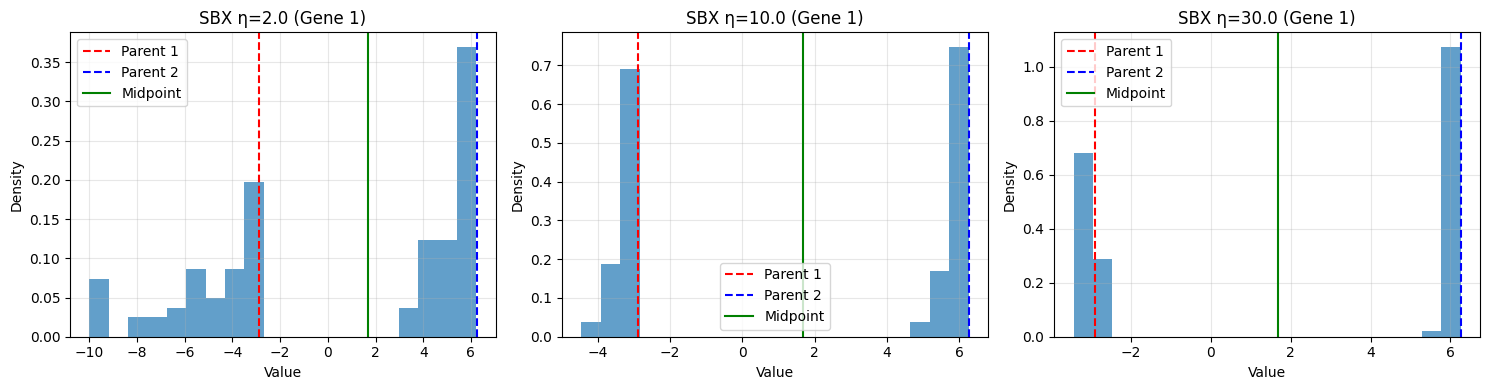

In [17]:
eta_values = [2.0, 10.0, 30.0]
key, *subkeys = jr.split(key, len(eta_values) + 1)

print("\nSimulated Binary Crossover (SBX) Analysis:")
print(f"Parent 1: {parent1_real.values}")
print(f"Parent 2: {parent2_real.values}")
print()

# Create figure for visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (eta, subkey) in enumerate(zip(eta_values, subkeys)):
    sbx_op = SimulatedBinaryCrossover(eta=eta, crossover_rate=1.0, num_offspring=2)
    
    print(f"Eta = {eta}:")
    
    # Generate multiple offspring pairs to analyze distribution
    subkey, *pair_keys = jr.split(subkey, 101)
    collected_children = []
    
    for pk in pair_keys:
        offspring = sbx_op._recombine_one(
            p1=parent1_real,
            p2=parent2_real,
            noise_data=sbx_op._generate_noise(
                keys=jr.split(pk, 2),
                config=real_config),
            config=real_config
        )
        if isinstance(offspring, (tuple, list)):
            for child in offspring:
                collected_children.append(jnp.asarray(child.values))
        elif hasattr(offspring, "values"):
            collected_children.append(jnp.asarray(offspring.values))
        else:
            collected_children.append(jnp.asarray(offspring))
    
    if len(collected_children) == 0:
        raise RuntimeError("No offspring were generated for SBX; check key splitting.")
    
    offspring_array = jnp.stack(collected_children)
    std_dev = jnp.std(offspring_array[:, 0])
    mean_val = jnp.mean(offspring_array[:, 0])
    parent_mean = 0.5 * (parent1_real.values[0] + parent2_real.values[0])
    
    print(f"  First gene - Mean: {mean_val:.3f}, Std: {std_dev:.3f}")
    print(f"  Parent midpoint: {parent_mean:.3f}")
    
    axes[idx].hist(offspring_array[:, 0], bins=20, alpha=0.7, density=True)
    axes[idx].axvline(parent1_real.values[0], color='red', linestyle='--', label='Parent 1')
    axes[idx].axvline(parent2_real.values[0], color='blue', linestyle='--', label='Parent 2')
    axes[idx].axvline(parent_mean, color='green', linestyle='-', label='Midpoint')
    axes[idx].set_title(f'SBX η={eta} (Gene 1)')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Density')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    
    print()

plt.tight_layout()
plt.show()

### Binomial Crossover (DE Style)

**Binomial Crossover** is primarily used in **Differential Evolution** algorithms. It creates a trial vector by selecting genes from a target (parent) or mutant vector.

**Algorithm**:
1. For each gene i: Generate random probability pᵢ
2. If pᵢ < crossover_rate: Take gene from mutant (Parent 1)
3. Otherwise: Take gene from target (Parent 2)
4. Ensure at least one gene comes from mutant

**Context**: Usually Parent 1 = mutant vector, Parent 2 = target vector

**Characteristics**:
- **DE-specific**: Designed for differential evolution
- **Directional**: Biased toward exploring mutant direction

## Part 3: Performance Analysis

Let's analyze the computational performance of different crossover operators.

In [18]:
large_binary_config = BinaryGenomeConfig(shape=(1000,), dtype=jnp.bool_)
large_real_config = RealGenomeConfig(shape=(100,), bounds=(-10.0, 10.0), dtype=jnp.float32)

key, k1, k2, k3, k4 = jr.split(key, 5)
large_binary_p1 = BinaryGenome.random_init(k1, large_binary_config)
large_binary_p2 = BinaryGenome.random_init(k2, large_binary_config)
large_real_p1 = RealGenome.random_init(k3, large_real_config)
large_real_p2 = RealGenome.random_init(k4, large_real_config)

print("Performance Benchmarking:")
print(f"Binary genomes: {large_binary_config.shape[0]} bits")
print(f"Real genomes: {large_real_config.shape[0]} genes")
print()

Performance Benchmarking:
Binary genomes: 1000 bits
Real genomes: 100 genes



In [26]:
def benchmark_crossover(operator:callable,
                        parent1: RealGenome | BinaryGenome,
                        parent2: RealGenome | BinaryGenome,
                        config: Any,
                        name: str,
                        num_trials: int = 1000) -> tuple[float, float]:
    """Benchmark a crossover operator."""
    def operator_fn (key, p1, p2, config):
        return operator._cross_fused(
            keys=jr.split(key, operator.num_keys_per_atomic_operation),
            p1=p1,
            p2=p2,
            config=config
        )
    
    key_warmup = jr.PRNGKey(123)
    _ = operator_fn(key_warmup, parent1, parent2, config)
    
    keys = jr.split(jr.PRNGKey(456), num_trials)
    
    # Vectorized benchmarking
    def run_batch(keys_batch):
        return jax.vmap(lambda k: operator_fn(k, parent1, parent2, config))(keys_batch)
    
    # Time the operations
    start_time = time()
    results = run_batch(keys)
    # Force computation by accessing a representative array safely

    sample = results[0]

    _ = sample.block_until_ready()
    end_time = time()
    
    total_time = end_time - start_time
    ops_per_second = num_trials / total_time
    
    return ops_per_second, total_time

In [28]:
# Benchmark real-valued operators
real_operators = [
    (RealUniformCrossover(num_offspring=2), "Real Uniform"),
    (BlendCrossover(alpha=0.5), "Blend (α=0.5)"),
    (SimulatedBinaryCrossover(eta=20.0, num_offspring=2), "SBX (η=20)"),
    (BinomialCrossover(), "Binomial")
]

print("Real-Valued Crossover Performance:")
print("Operator        | Ops/sec  | Time (ms)")
print("-" * 40)

for op, name in real_operators:
    ops_per_sec, total_time = benchmark_crossover(
        op, large_real_p1, large_real_p2, large_real_config, name, 100
    )
    print(f"{name:15s} | {ops_per_sec:8.1f} | {total_time*10:.2f}")

Real-Valued Crossover Performance:
Operator        | Ops/sec  | Time (ms)
----------------------------------------
Real Uniform    |   3661.4 | 0.27
Blend (α=0.5)   |    717.7 | 1.39
SBX (η=20)      |   4311.8 | 0.23
Binomial        |  24618.8 | 0.04


## Part 4: Crossover Comparison Analysis 📈

Let's compare how different crossover operators affect population diversity and convergence patterns.

Diversity Analysis - Binary Operators:

Diversity Analysis - Real Operators:


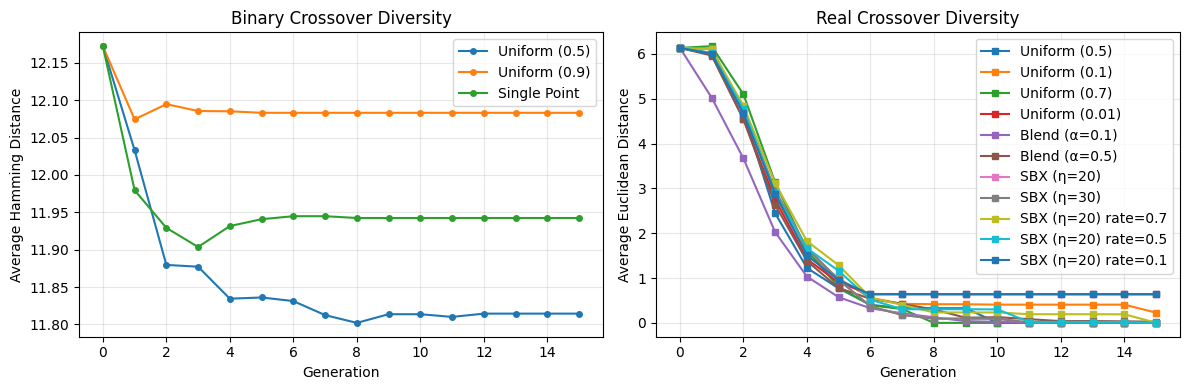


Observations:
- Higher crossover rates generally reduce diversity faster
- Blend crossover with higher α maintains more diversity
- Single-point crossover preserves some population structure
- SBX with high η (20) is conservative, maintains diversity
- SBX with higher η values (30, 40) are even more conservative, preserving diversity further


In [29]:
def analyze_diversity_preservation(crossover_op, config, num_generations=10, pop_size=50):
    """Analyze how crossover affects population diversity over generations."""
    
    # Initialize diverse population
    key_init = jr.PRNGKey(789)
    
    if isinstance(config, BinaryGenomeConfig):
        population = BinaryPopulation.init_random(key_init, config, pop_size)
        metric = "hamming"
    else:
        population = RealPopulation.init_random(key_init, config, pop_size)
        metric = "euclidean"
    
    # Calculate initial diversity as mean pairwise distance
    dist_matrix = population.distance_matrix(metric=metric)
    # Get upper triangle (excluding diagonal) and average
    initial_diversity = jnp.mean(jnp.triu(dist_matrix, k=1))
    diversities = [float(initial_diversity)]
    
    # Simulate generations of crossover
    for gen in range(num_generations):
        key_gen = jr.PRNGKey(gen + 1000)
        offspring_list = []
        
        # Generate offspring through crossover
        for i in range(0, pop_size, 2):
            parent1 = population[i]
            parent2 = population[(i + 1) % pop_size]
            
            key_gen, subkey = jr.split(key_gen)
            
            # Use cross_single_pair for single pair crossover
            # Returns batched genome with shape (num_offspring, ...)
            offspring_batch = crossover_op.cross_single_pair(subkey, parent1, parent2, config)
            
            # Extract individual offspring from batch
            if isinstance(config, BinaryGenomeConfig):
                for j in range(offspring_batch.values.shape[0]):
                    offspring_list.append(BinaryGenome(values=offspring_batch.values[j]))
            else:
                for j in range(offspring_batch.values.shape[0]):
                    offspring_list.append(RealGenome(values=offspring_batch.values[j]))
            
            # Ensure we don't exceed population size
            if len(offspring_list) >= pop_size:
                break
        
        # Create new population from offspring (truncate to pop_size if needed)
        offspring_list = offspring_list[:pop_size]
        
        if isinstance(config, BinaryGenomeConfig):
            # Stack offspring into batched genome
            offspring_genes = BinaryGenome(
                values=jnp.stack([g.values for g in offspring_list])
            )
            population = BinaryPopulation(
                genes=offspring_genes,
                fitness=jnp.full((len(offspring_list),), -jnp.inf),
                config=config
            )
        else:
            # Stack offspring into batched genome
            offspring_genes = RealGenome(
                values=jnp.stack([g.values for g in offspring_list])
            )
            population = RealPopulation(
                genes=offspring_genes,
                fitness=jnp.full((len(offspring_list),), -jnp.inf),
                config=config
            )
        
        # Calculate diversity for this generation
        dist_matrix = population.distance_matrix(metric=metric)
        gen_diversity = jnp.mean(jnp.triu(dist_matrix, k=1))
        diversities.append(float(gen_diversity))
    
    return diversities

# Analyze diversity for binary operators
print("Diversity Analysis - Binary Operators:")
binary_config_small = BinaryGenomeConfig(shape=(50,), dtype=jnp.bool_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

binary_ops_analysis = [
    (BinaryUniformCrossover(crossover_rate=0.5), "Uniform (0.5)"),
    (BinaryUniformCrossover(crossover_rate=0.9), "Uniform (0.9)"),
    (SinglePointCrossover(), "Single Point")
]

for op, name in binary_ops_analysis:
    diversities = analyze_diversity_preservation(op, binary_config_small, num_generations=15)
    ax1.plot(diversities, label=name, marker='o', markersize=4)

ax1.set_title('Binary Crossover Diversity')
ax1.set_xlabel('Generation')
ax1.set_ylabel('Average Hamming Distance')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Analyze diversity for real operators
print("\nDiversity Analysis - Real Operators:")
real_config_small = RealGenomeConfig(shape=(10,), bounds=(-5.0, 5.0), dtype=jnp.float32)

real_ops_analysis = [
    (RealUniformCrossover(crossover_rate=0.5), "Uniform (0.5)"),
    (RealUniformCrossover(crossover_rate=0.1), "Uniform (0.1)"),
    (RealUniformCrossover(crossover_rate=0.7), "Uniform (0.7)"),
    (RealUniformCrossover(crossover_rate=0.01), "Uniform (0.01)"),
    (BlendCrossover(alpha=0.1, crossover_rate=1.0), "Blend (α=0.1)"),
    (BlendCrossover(alpha=0.5, crossover_rate=1.0), "Blend (α=0.5)"),
    (SimulatedBinaryCrossover(eta=20.0, crossover_rate=1.0, num_offspring=1), "SBX (η=20)"),
    (SimulatedBinaryCrossover(eta=30.0, crossover_rate=1.0, num_offspring=1), "SBX (η=30)"),
    (SimulatedBinaryCrossover(eta=20.0, crossover_rate=.7, num_offspring=1), "SBX (η=20) rate=0.7"),
    (SimulatedBinaryCrossover(eta=20.0, crossover_rate=.5, num_offspring=1), "SBX (η=20) rate=0.5"),
    (SimulatedBinaryCrossover(eta=20.0, crossover_rate=.001, num_offspring=1), "SBX (η=20) rate=0.1")
]

for op, name in real_ops_analysis:
    diversities = analyze_diversity_preservation(op, real_config_small, num_generations=15)
    ax2.plot(diversities, label=name, marker='s', markersize=4)

ax2.set_title('Real Crossover Diversity')
ax2.set_xlabel('Generation')
ax2.set_ylabel('Average Euclidean Distance')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- Higher crossover rates generally reduce diversity faster")
print("- Blend crossover with higher α maintains more diversity")
print("- Single-point crossover preserves some population structure")
print("- SBX with high η (20) is conservative, maintains diversity")
print("- SBX with higher η values (30, 40) are even more conservative, preserving diversity further")

## Summary and Best Practices

### Crossover Operator Selection Guide

| Problem Type | Recommended Operator | Parameters | Use Case |
|--------------|---------------------|------------|----------|
| **Binary/Combinatorial** | Uniform Crossover | rate=0.5 | General mixing |
| **Binary/Building Blocks** | Single-Point | default | Preserve adjacency |
| **Real/Independent Genes** | Real Uniform | rate=0.6 | Gene independence |
| **Real/Exploration** | Blend (BLX-α) | α=0.5 | High diversity |
| **Real/Exploitation** | SBX | η=20-30 | Parent-centric |

### Key Design Principles

1. **3-Tier Separation**: Always separate RNG (Tier 3), noise generation (Tier 2), and arithmetic (Tier 1)
2. **JIT Compatibility**: Use `@struct.dataclass` and pure functions for compilation
3. **Batch Processing**: Leverage `jax.vmap` for population-level operations
4. **Parameter Tuning**: Adjust crossover rates and operator-specific parameters based on problem characteristics

### Performance Considerations

- **Memory**: Operators with `num_offspring > 1` use more memory
- **Computation**: Complex operators (SBX, Blend) have higher computational cost
- **JIT Compilation**: Always JIT-compile operators for production use
- **Vectorization**: Use population-level operations when possible


## Part 6: Custom Crossover Implementation

Let's implement a custom crossover operator extending `BaseCrossover` to demonstrate the full 3-tier paradigm.

In [ ]:
from malthusjax.operators.base import BaseCrossover
from typing import Any, Tuple
import chex
import flax.struct

@flax.struct.dataclass
class AdaptiveAlphaCrossover(BaseCrossover[RealGenome, RealGenomeConfig, RealPopulation]):
    """
    Adaptive Alpha Blend Crossover - Custom Implementation.
    
    Demonstrates the 3-tier paradigm with adaptive exploration:
    - Tier 3: Population-level orchestration (inherited)
    - Tier 2: Generate adaptive alpha based on parent distance
    - Tier 1: Pure arithmetic blending with adaptive parameters
    
    Key idea: Adjust blend factor α based on parent genetic distance
    - Close parents → Conservative blending (low α)
    - Distant parents → Exploratory blending (high α)
    """
    num_offspring: int = flax.struct.field(pytree_node=False, default=1)
    min_alpha: float = 0.1
    max_alpha: float = 0.8
    distance_scale: float = 1.0
    crossover_rate: float = 0.95

    @property
    def num_keys_per_atomic_operation(self) -> int:
        """Requires 2 keys: decision to cross + uniform sampling."""
        return 2

    def _generate_noise(self, keys: chex.PRNGKey, config: RealGenomeConfig) -> Tuple[chex.Array, chex.Array]:
        """
        Tier 2 — Generate stochastic components.
        Returns: (should_cross, uniform_samples)
        """
        k_decision, k_uniform = keys[0], keys[1]
        
        should_cross = jax.random.bernoulli(k_decision, p=self.crossover_rate)
        uniform_samples = jax.random.uniform(k_uniform, shape=config.shape, dtype=config.dtype)
        
        return should_cross, uniform_samples

    def _recombine_one(
        self,
        p1: RealGenome,
        p2: RealGenome,
        noise_data: Tuple[chex.Array, chex.Array],
        config: RealGenomeConfig,
        **kwargs: Any
    ) -> RealGenome:
        """
        Tier 1 — Pure arithmetic recombination with adaptive alpha.
        """
        should_cross, uniform_vals = noise_data
        dtype = config.dtype
        
        # 1. Calculate adaptive alpha based on parent distance
        parent_distance = p1.distance(p2, metric="euclidean")
        
        # Normalize distance to [0, 1] using sigmoid-like function
        normalized_distance = jnp.tanh(parent_distance * self.distance_scale)
        
        # Adaptive alpha: closer parents → lower alpha, distant parents → higher alpha
        adaptive_alpha = self.min_alpha + (self.max_alpha - self.min_alpha) * normalized_distance
        adaptive_alpha = jnp.array(adaptive_alpha, dtype=dtype)
        
        # 2. Standard BLX-α arithmetic with adaptive alpha
        diff = jnp.abs(p1.values - p2.values)
        cmin = jnp.minimum(p1.values, p2.values) - (adaptive_alpha * diff)
        cmax = jnp.maximum(p1.values, p2.values) + (adaptive_alpha * diff)
        
        # 3. Blend interpolation
        blended_values = cmin + uniform_vals * (cmax - cmin)
        
        # 4. Apply boundary constraints
        min_bound, max_bound = config.bounds
        blended_values = jnp.clip(blended_values, min_bound, max_bound)
        
        # 5. Conditional application based on crossover decision
        final_values = jnp.where(should_cross, blended_values, p1.values)
        
        return p1.replace(values=final_values)

print("Custom AdaptiveAlphaCrossover defined!")
print("\nKey features:")
print("- Extends BaseCrossover with adaptive parameter logic")
print("- Uses genome.distance() for efficient distance computation")
print("- Follows 3-tier paradigm: RNG (Tier 2) → Arithmetic (Tier 1)")
print("- Compatible with JIT compilation via @struct.dataclass")

✅ Custom AdaptiveAlphaCrossover defined!

Key features:
- Extends BaseCrossover with adaptive parameter logic
- Uses genome.distance() for efficient distance computation
- Follows 3-tier paradigm: RNG (Tier 2) → Arithmetic (Tier 1)
- Compatible with JIT compilation via @struct.dataclass


In [30]:
adaptive_custom = AdaptiveAlphaCrossover(
    min_alpha=0.1,
    max_alpha=0.8,
    distance_scale=0.5,
    crossover_rate=1.0  # Always cross for demonstration
)

test_config = RealGenomeConfig(shape=(3,), bounds=(-10.0, 10.0), dtype=jnp.float32)

print("\n" + "="*60)
print("Testing Custom AdaptiveAlphaCrossover")
print("="*60)

# Test cases: parents at different distances
test_cases = [
    ("Close Parents", 
     RealGenome(values=jnp.array([0.0, 0.0, 0.0], dtype=jnp.float32)), 
     RealGenome(values=jnp.array([0.1, 0.1, 0.1], dtype=jnp.float32))),
    
    ("Medium Distance", 
     RealGenome(values=jnp.array([0.0, 0.0, 0.0], dtype=jnp.float32)), 
     RealGenome(values=jnp.array([2.0, 2.0, 2.0], dtype=jnp.float32))),
    
    ("Far Parents", 
     RealGenome(values=jnp.array([-5.0, -5.0, -5.0], dtype=jnp.float32)), 
     RealGenome(values=jnp.array([5.0, 5.0, 5.0], dtype=jnp.float32)))
]

key_test, *test_keys = jr.split(jr.PRNGKey(999), len(test_cases) + 1)

for (case_name, p1, p2), test_key in zip(test_cases, test_keys):
    # Get parent distance and expected adaptive alpha
    distance = p1.distance(p2, metric="euclidean")
    normalized_dist = jnp.tanh(distance * adaptive_custom.distance_scale)
    expected_alpha = adaptive_custom.min_alpha + (adaptive_custom.max_alpha - adaptive_custom.min_alpha) * normalized_dist
    
    print(f"\n{case_name}:")
    print(f"  Parent 1:    {p1.values}")
    print(f"  Parent 2:    {p2.values}")
    print(f"  Distance:    {float(distance):.4f}")
    print(f"  Adaptive α:  {float(expected_alpha):.4f}")
    
    # Generate multiple offspring to show exploration behavior
    test_key, *offspring_keys = jr.split(test_key, 6)
    offspring_list = []
    
    for ok in offspring_keys:
        offspring = adaptive_custom.cross_single_pair(ok, p1, p2, test_config)
        # Extract single offspring (num_offspring=1)
        offspring_list.append(offspring.values[0])
    
    offspring_array = jnp.stack(offspring_list)
    
    # Calculate statistics
    std_dev = jnp.std(offspring_array, axis=0)
    mean_offspring = jnp.mean(offspring_array, axis=0)
    
    print(f"  Offspring mean:  {mean_offspring}")
    print(f"  Offspring std:   {std_dev}")
    print(f"  Interpretation:  {'Conservative' if float(expected_alpha) < 0.3 else 'Exploratory' if float(expected_alpha) > 0.6 else 'Balanced'}")


Testing Custom AdaptiveAlphaCrossover

Close Parents:
  Parent 1:    [0. 0. 0.]
  Parent 2:    [0.1 0.1 0.1]
  Distance:    0.1732
  Adaptive α:  0.1605
  Offspring mean:  [0.04243128 0.06631625 0.06136128]
  Offspring std:   [0.01850885 0.03102521 0.02639187]
  Interpretation:  Conservative

Medium Distance:
  Parent 1:    [0. 0. 0.]
  Parent 2:    [2. 2. 2.]
  Distance:    3.4641
  Adaptive α:  0.7575
  Offspring mean:  [0.68783766 0.68619126 2.4687736 ]
  Offspring std:   [1.400256   0.56748694 0.49118298]
  Interpretation:  Exploratory

Far Parents:
  Parent 1:    [-5. -5. -5.]
  Parent 2:    [5. 5. 5.]
  Distance:    17.3205
  Adaptive α:  0.8000
  Offspring mean:  [-0.685373    0.6285362   0.03851509]
  Offspring std:   [7.3282347 5.6372795 8.595764 ]
  Interpretation:  Exploratory
